In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

In [2]:
d_in = 2
teacher_weights = np.random.randn(d_in)
teacher_weights /= np.linalg.norm(teacher_weights)
def generate_data(B: int, d_in: int):
    x = np.random.randn(B, d_in)
    y = (x @ teacher_weights)
    return x, y.reshape(-1, 1)

256
512
1024
2048
4096


(0.0, 0.3)

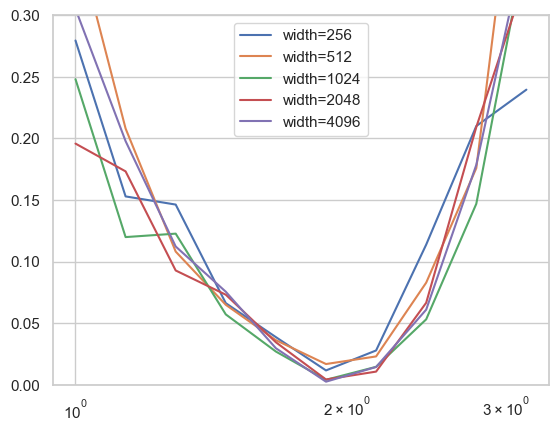

In [3]:
B=10000
LRs = np.logspace(0.0, 0.5, 10)
X, y = generate_data(B, d_in)
for width in [256, 512, 1024, 2048, 4096]:
    print(width)
    losses_mean = {}
    for eta in LRs:
        losses = []
        for _ in range(25):
            W0 = np.random.randn(d_in, width) / (np.sqrt(d_in))
            W1 = np.random.randn(width, width) 
            W2 = np.random.randn(width, 1) / width
            h0 = X @ W0                 
            y_hat = h0 @ W1 @ W2       # (B, 1)
            d_yhat = (y_hat - y) / B             
            dW1 = h0.T @ (d_yhat @ W2.T)            
            W1 -= eta * dW1
            y_hat = h0 @ W1 @ W2
            losses.append(0.5 * np.mean((y_hat - y) ** 2))
        losses_mean[eta] = np.mean(losses)
    plt.plot(losses_mean.keys(), losses_mean.values(), label=f'width={width}')
plt.legend()
plt.xscale('log')
plt.ylim(0, 0.3)